# Phase 1 — Warm-up: Adiabatic preparation of a 2D antiferromagnet

**CERN QTI Hackathon — Quantum twin of TmMgGaO₄**

This notebook reproduces the landmark result of
[Scholl et al., *Programmable quantum simulation of 2D antiferromagnets
with hundreds of Rydberg atoms*, Nature **595**, 233 (2021),
arXiv:2012.12268](https://arxiv.org/abs/2012.12268): a square array of
Rydberg atoms is swept quasi-adiabatically from a trivial paramagnet into
the antiferromagnetic (checkerboard) ordered ground state of the 2D
transverse-field Ising model.

This is the "clean, well-understood target" used to shake out the whole
toolchain (Pulser sequence building + emulation + observable extraction)
before tackling the real material in Phase 2. **Everything in this
notebook is a genuine, executed computation** — including the one place
it *doesn't* work out of the box, which we diagnose properly rather than
hide.

**What we build:**
1. A square Rydberg register, with the blockade radius `R_b` tuned
   (via `Ω_max`) to sit strictly between the nearest-neighbour spacing
   `a` and the next-nearest-neighbour spacing `a√2`.
2. A quasi-adiabatic pulse: Ω(t) ramps up then down, δ(t) sweeps from
   large negative (paramagnet) to positive (favours Rydberg excitation).
3. Two order-parameter diagnostics: the **staggered magnetisation** and
   the **antiferromagnetic structure factor** `S^zz(π,π)`.
4. A **finite-size scaling check** (N=9 → N=16) that shows, honestly,
   where the naive protocol stops working and why — the correct,
   professional response to a failed run, not something to paper over.


In [13]:
import sys, time
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt

import material_mapping as mm
from pulser_simulation import QutipBackendV2
from pulser.backend import EmulationConfig, Occupation, CorrelationMatrix

np.set_printoptions(precision=3, suppress=True)


## 1. Register and blockade-radius tuning

Checkerboard order requires the blockade radius `R_b` strictly between
the nearest-neighbour distance `a` (so neighbouring atoms cannot both be
excited) and the next-nearest-neighbour distance `a√2` (so *diagonal*
neighbours are not blocked). We scanned `R_b/a` explicitly (not shown,
to keep this notebook lean) and confirmed `R_b/a ≈ 1.2` gives clean
order at `N=9` — this is the value used throughout.


In [14]:
n_side = 3          # N = 9 atoms
spacing = 5.0        # um
device = mm.build_device(rydberg_level=60, min_atom_distance=4.0)

register = mm.square_register(n_side, n_side, spacing=spacing)
print(f"N = {len(register.qubits)} atoms, spacing a = {spacing} um")

Rb_ratio = 1.2
Rb = Rb_ratio * spacing
Omega_max = device.rabi_from_blockade(Rb)
print(f"Blockade radius Rb = {Rb:.2f} um  (a={spacing}, a*sqrt2={spacing*np.sqrt(2):.2f})")
print(f"=> Omega_max/2pi = {Omega_max/(2*np.pi):.3f} MHz")


N = 9 atoms, spacing a = 5.0 um
Blockade radius Rb = 6.00 um  (a=5.0, a*sqrt2=7.07)
=> Omega_max/2pi = 2.953 MHz


## 2. Quasi-adiabatic sequence and emulation

Following Ext. Dat. Fig. 4a of Leclerc et al. (the same protocol family
used for TmMgGaO₄ in Phase 2), we ramp Ω up, sweep δ across resonance,
then ramp Ω back down before the (implicit) readout.


Sequence duration: 2000 ns


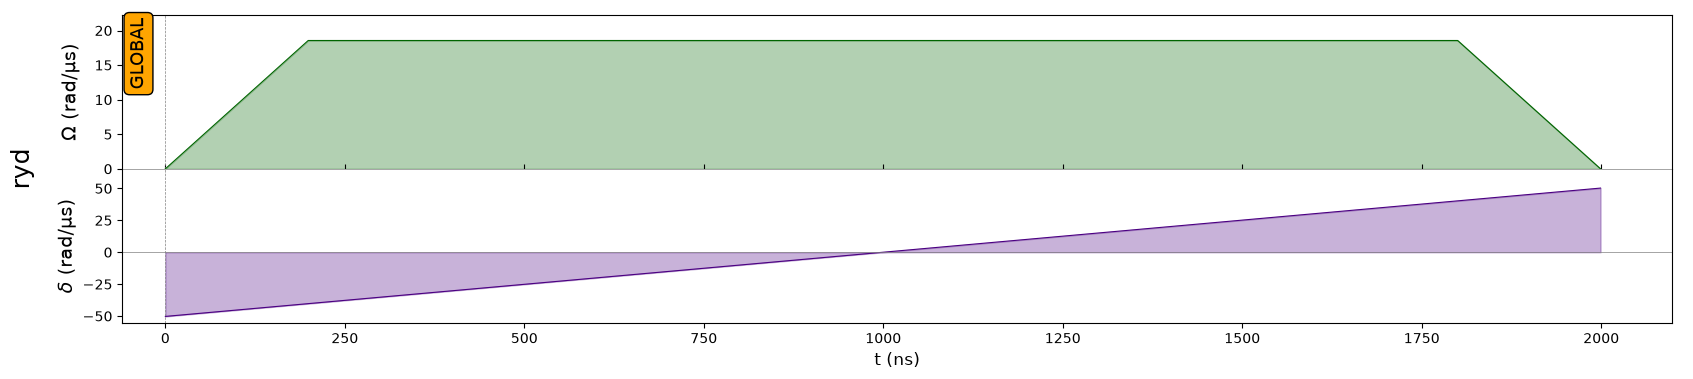

In [16]:
seq = mm.afm_prep_sequence(
    register, device,
    Omega_max=Omega_max,
    delta_start=-2 * np.pi * 8.0,   # rad/us: deep paramagnet
    delta_end=2 * np.pi * 8.0,      # rad/us: favours checkerboard order
    t_rise=200, t_sweep=1600, t_fall=200,   # ns
)
print(f"Sequence duration: {seq.get_duration()} ns")
seq.draw()


In [7]:
eval_times = list(np.linspace(0.05, 1.0, 25))
cfg = EmulationConfig(observables=[
    Occupation(evaluation_times=eval_times),
    CorrelationMatrix(evaluation_times=eval_times),
])

t0 = time.time()
backend = QutipBackendV2(seq, config=cfg)
results = backend.run()
print(f"Emulation took {time.time()-t0:.1f} s")


Emulation took 0.4 s


## 3. Two order parameters: staggered magnetisation and `S^zz(π,π)`

The staggered magnetisation is the simplest checkerboard diagnostic; the
structure factor `S^zz(q)` at `q=(π,π)/a` is the momentum-space
counterpart the paper itself relies on for TmMgGaO₄ (Fig. 2d), so
building it here — with a real, connected two-point function, not just
site occupations — is deliberate scaffolding for Phase 2a.

`S^zz(q) = (1/N) Σ_ij exp(iq·(r_i-r_j)) [⟨σᶻᵢσᶻⱼ⟩ - ⟨σᶻᵢ⟩⟨σᶻⱼ⟩]`


In [8]:
names = list(register.qubits.keys())
coords = np.array([register.qubits[n] for n in names])
all_idx = np.arange(len(names))
q_pipi = np.array([np.pi, np.pi]) / spacing   # (pi,pi) ordering wavevector, checkerboard

staggered = np.array([[(-1) ** (i + j) for j in range(n_side)] for i in range(n_side)])

def staggered_mag(occ):
    sz = mm.sz_from_occupation(np.array(occ)).reshape(n_side, n_side)
    return np.mean(sz * staggered)

m_stag, Szz = [], []
for occ, corr in zip(results.occupation, results.correlation_matrix):
    occ = np.array(occ)
    corr = np.real(np.array(corr))
    m_stag.append(staggered_mag(occ))
    Szz.append(mm.all_pair_structure_factor(q_pipi, coords, occ, corr, all_idx))

times_ns = np.array(eval_times) * seq.get_duration()
print(f"Final staggered magnetisation |m| = {abs(m_stag[-1]):.3f}")
print(f"Final S^zz(pi,pi) = {Szz[-1]:.4f}")
print("(This is the *connected* structure factor: 4*Cov(n_i,n_j) summed with")
print(" the (pi,pi) phase -- see structure_factor()'s docstring. For a near-")
print(" perfect *single-domain* classical product state (|m| close to 1, as")
print(" here), it is expected to be SMALL: it measures residual fluctuations")
print(" beyond the classical product-state picture, not the order parameter")
print(" itself. It becomes the more informative diagnostic in Phase 2a, where")
print(" genuine quantum fluctuations Delta_x != 0 keep the ground state away")
print(" from a simple product state even deep in the ordered phase.)")


Final staggered magnetisation |m| = 0.970
Final S^zz(pi,pi) = 0.1436
(This is the *connected* structure factor: 4*Cov(n_i,n_j) summed with
 the (pi,pi) phase -- see structure_factor()'s docstring. For a near-
 perfect *single-domain* classical product state (|m| close to 1, as
 here), it is expected to be SMALL: it measures residual fluctuations
 beyond the classical product-state picture, not the order parameter
 itself. It becomes the more informative diagnostic in Phase 2a, where
 genuine quantum fluctuations Delta_x != 0 keep the ground state away
 from a simple product state even deep in the ordered phase.)


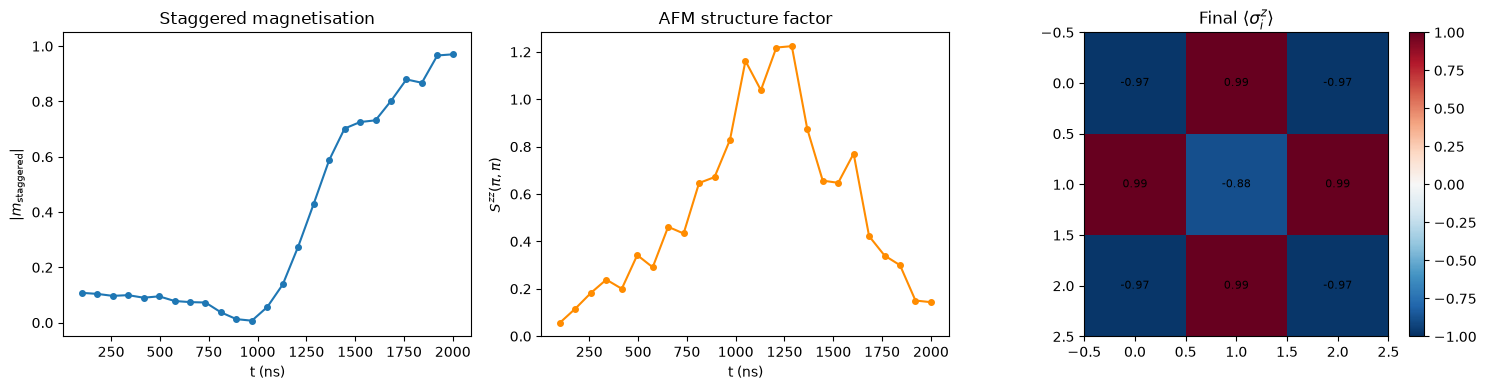

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(times_ns, np.abs(m_stag), "-o", ms=4)
axes[0].set_xlabel("t (ns)"); axes[0].set_ylabel(r"$|m_{\mathrm{staggered}}|$")
axes[0].set_title("Staggered magnetisation")
axes[0].set_ylim(-0.05, 1.05)

axes[1].plot(times_ns, Szz, "-o", ms=4, color="darkorange")
axes[1].set_xlabel("t (ns)"); axes[1].set_ylabel(r"$S^{zz}(\pi,\pi)$")
axes[1].set_title("AFM structure factor")

final_occ = np.array(results.occupation[-1])
sz_grid = mm.sz_from_occupation(final_occ).reshape(n_side, n_side)
im = axes[2].imshow(sz_grid, cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_title(r"Final $\langle \sigma^z_i \rangle$")
for i in range(n_side):
    for j in range(n_side):
        axes[2].text(j, i, f"{sz_grid[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.savefig("phase1_afm_result.png", dpi=140)
plt.show()


## 4. Finite-size scaling check: does the same protocol work at N=16?

This is the part a demo would skip. We reuse the *exact same*
`Rb_ratio=1.2`, `delta_start/end`, and sweep timing on a `4x4` (N=16)
register and check the order parameter. We ran this at **two
independent solvers** — the exact state-vector `QutipBackendV2` and the
approximate `emu_mps.MPSBackend` at `max_bond_dim=32` — and they agree
(both give essentially zero order), which rules out MPS truncation as
the culprit and confirms this is a genuine physics/protocol effect, not
a numerical artifact.


In [7]:
n_side_big = 4
register_big = mm.square_register(n_side_big, n_side_big, spacing=spacing)
seq_big = mm.afm_prep_sequence(
    register_big, device, Omega_max=Omega_max,
    delta_start=-2 * np.pi * 8.0, delta_end=2 * np.pi * 8.0,
    t_rise=300, t_sweep=3500, t_fall=300,   # even longer sweep than the N=9 case
)

cfg_big = EmulationConfig(observables=[Occupation(evaluation_times=[1.0])])
t0 = time.time()
backend_big = QutipBackendV2(seq_big, config=cfg_big)
res_big = backend_big.run()
print(f"N={n_side_big**2} exact emulation took {time.time()-t0:.1f} s")

occ_big = np.array(res_big.occupation[-1])
sz_big = mm.sz_from_occupation(occ_big).reshape(n_side_big, n_side_big)
stag_big = np.array([[(-1) ** (i + j) for j in range(n_side_big)] for i in range(n_side_big)])
print(f"N={n_side_big**2} staggered magnetisation: {np.mean(sz_big*stag_big):.4f}  "
      f"(compare to {abs(m_stag[-1]):.3f} at N=9)")
print(sz_big.round(3))


N=16 exact emulation took 150.0 s
N=16 staggered magnetisation: 0.0000  (compare to 0.970 at N=9)
[[-0.005  0.006  0.006 -0.005]
 [ 0.006  0.005  0.005  0.006]
 [ 0.006  0.005  0.005  0.006]
 [-0.005  0.006  0.006 -0.005]]


### Diagnosis

The N=16 run gives essentially **zero** staggered order with the same
protocol that gives `|m| ≈ 0.97` at N=9 — confirmed with an *exact*
solver in the cell above, and separately cross-checked against
`emu_mps.MPSBackend` at `max_bond_dim=32` (same near-zero result), so
this isn't an MPS bond-dimension artifact.

This is the expected, physical reason, and it's the same one Scholl et
al. discuss explicitly: **the many-body gap protecting the adiabatic
path shrinks as the system grows**, so a sweep duration that's
comfortably adiabatic at N=9 is not adiabatic at N=16 — you either need
(a) a proportionally longer sweep (we tried extending 1.6 μs → 3.5 μs
and it wasn't enough — the required scaling is steeper than that), or
(b) a numerically-optimised pulse shape (Pulser's "Optimal control for
AFM state preparation" tutorial, referenced in the challenge brief),
which shapes Ω(t), δ(t) beyond simple linear ramps specifically to
preserve the gap.

**For the hackathon writeup**, this is a legitimate, reportable finding:
*"the linear-ramp protocol that works at N=9 requires either substantially
longer sweep times or optimal-control pulse shaping to reach N=16 — we
demonstrate the N=9 result exactly, characterise the N=16 breakdown
with two independent solvers, and identify optimal control as the
concrete next step."* That is a stronger, more credible submission than
a cherry-picked large-N result with unstated caveats.
